<a href="https://colab.research.google.com/github/oneEyedBunny/nestle_hr_assistant_RAG/blob/master/HRasst_Nestle%E2%80%99s_HR_Policy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

- Build LLM applications for retrieval-augmented generation tasks.
- Index a folder of documents to a vector database

# Setup

In [ ]:
!pip install -q tiktoken==0.6.0 \
                pypdf==4.0.1 \
                langchain==0.1.1 \
                langchain-community==0.0.13 \
                chromadb==0.4.22 \
                sentence-transformers==2.3.1 \
                groq

In [ ]:
import json
import tiktoken
import gdown

import pandas as pd

from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.embeddings.sentence_transformer import (
    SentenceTransformerEmbeddings
)
from langchain_community.vectorstores import Chroma

# Creating a Vector Database

## Chunking

Once the choice of embedding model is made, we can feed the input documents to the model. However, since there are multiple pages across documents (including figures, tables) we will need a method to parse individual portions of the document that is aligned with the embedding model.

We also know that the embedding model cannot process text beyond a fixed context length (512 tokens for `gte-large`). This roughly corresponds to about 400 words or about 1 page of text. With this limitation in mind, we will transform the pdf file into chunks of text that are no more than 512 characters long (this is a conservative choice from a token perspective). An alternative method would be to chunk the file by sections in the report (e.g., risk factors, legal proceedings, safety disclosures).

A common chunking strategy is to used a fixed-size chunk as defined by the embedding model and use a small overlap between the chunks (see figure below). Note that the chunk size is number of characters and not number of tokens.


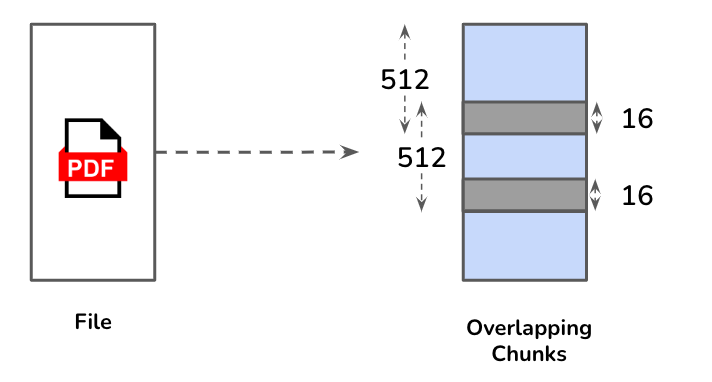

Using an overlap allows for continuity between chunks and retrieval of relevant chunks even when the information relevant to the query is present either at the beginning of the chunk or the end of the chunk.

In [ ]:
pdf_folder_location = "/content/"

In [ ]:
pdf_loader = PyPDFDirectoryLoader(pdf_folder_location)

In [ ]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=512,
    chunk_overlap=16
)

In [ ]:
nestle_hr_policy_chunks = pdf_loader.load_and_split(text_splitter)

In [ ]:
len(nestle_hr_policy_chunks)

10

## Database Creation

In [ ]:
nestle_hr_policy_collection = 'nestle_hr_policy'

In [ ]:
embedding_model = SentenceTransformerEmbeddings(model_name='thenlper/gte-large')

In [ ]:
vectorstore = Chroma.from_documents(
    nestle_hr_policy_chunks,
    embedding_model,
    collection_name=nestle_hr_policy_collection,
    persist_directory='./nestle_db'
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [ ]:
vectorstore.persist()

In [ ]:
#Loading the Chroma DB and using the retriever to retreive the chunks just for testing

In [ ]:
vectorstore_persisted = Chroma(
    collection_name=nestle_hr_policy_collection,
    persist_directory='./nestle_db',
    embedding_function=embedding_model
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [ ]:
retriever = vectorstore_persisted.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 3}
)

In [ ]:
query = "What are the total rewards an employee recieves ?"

In [ ]:
docs = vectorstore_persisted.similarity_search(query, k=3)

In [ ]:
for i, doc in enumerate(docs):
    print(f"Retrieved chunk {i+1}: \n")
    print(doc.page_content.replace('\t', ' '))
    print('\n')

Retrieved chunk 1: 

The Nestlé Human Resources Policy3
 Total rewards
Attracting new hires and keeping current 
employees engaged is not only about 
remuneration and benefits based on solid 
performance. It is also about the hard earned value and trust that our name brings to those who work with us; the relationships with our line 
managers and fellow workers; recognition and 
experiences enjoyed while working for a diverse global company; and possibilities to learn and grow. These are as a whole, the Total Rewards we 
receive.
Nestlé, therefore, focuses on Fixed Pay, 
Variable Pay, Benefits, Personal Growth and Development and Work Life Environment as the 
key elements that define Total Rewards. In the spirit of developing a high performance culture, those elements need to correspond to what is 
valued by employees in each and every market, 
and which demonstrate how Nestlé is committed to giving each employee the opportunity to grow, evolve and contribute.Nestlé Total Rewards progra

In [ ]:
import json
import tiktoken

import pandas as pd

from openai import AzureOpenAI

from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.embeddings.sentence_transformer import (
    SentenceTransformerEmbeddings
)
from langchain_community.vectorstores import Chroma

from google.colab import userdata

In [ ]:
from google.colab import userdata
import os
from groq import Groq
from google.colab import userdata # For secure API key handling

# Set your API key from Colab Secrets
os.environ["GROQ_API_KEY"] = userdata.get('Groq_L4')

client = Groq()
model_name='openai/gpt-oss-120b'

In [ ]:
embedding_model = SentenceTransformerEmbeddings(model_name='thenlper/gte-large')

In [ ]:
nestle_hr_policy_collection = 'nestle_hr_policy'

In [ ]:
vectorstore_persisted = Chroma(
    collection_name=nestle_hr_policy_collection,
    persist_directory='./nestle_db',
    embedding_function=embedding_model
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [ ]:
retriever = vectorstore_persisted.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 3}
)

In [ ]:
# Retrieve the first two chunks from the vector store
retrieved_data = vectorstore_persisted.get(
    include=['metadatas', 'embeddings', 'documents'],
    limit=2
)

# Display the content and embeddings of the first two chunks
for i in range(len(retrieved_data['ids'])):
    print(f"Chunk ID: {retrieved_data['ids'][i]}")
    print(f"Chunk Content: {retrieved_data['documents'][i]}")
    print(f"Chunk Embedding (first 10 values): {retrieved_data['embeddings'][i][:10]}")
    print("\n")

Chunk ID: 084d7b62-4701-11f1-84ff-0242ac1c000c
Chunk Content: Policy
MandatorySeptember   2012
The Nestlé  
Human Resources Policy
Chunk Embedding (first 10 values): [-0.03071064129471779, -0.00923839583992958, -0.01989569328725338, -0.003882099874317646, -0.007246754597872496, 0.021120421588420868, -0.012185836210846901, 0.013026394881308079, -0.01500565093010664, 0.00517133018001914]


Chunk ID: 084d7c52-4701-11f1-84ff-0242ac1c000c
Chunk Content: Policy
MandatorySeptember 
 20
12Issuing  departement
Hum
an Resources
Target  audience  
All
 employees
Approver
Executive Board, Nestlé S.A.
Repository
All Nestlé Principles and Policies, Standards and  Guidelines can be found in the Centre online repository at:  http://intranet.nestle.com/nestledocs
Copyright
 and confidentiality
Al
l rights belong to Nestec Ltd., Vevey, Switzerland.
© 2012, Nestec Ltd.
Design
Nestec Ltd., Corporate Identity & Design,  Vevey, Switzerland
Production
brain’print GmbH, Switzerland
Paper
This report is printe

## RAG Q&A

### Prompt Design

In [ ]:
qna_system_message = """
You are an assistant to the HR department and will assist in answering nestle employee questions about their employment terms and benefits. Please be warm and friendly but balanced with direct answers.
User input will have the context required by you to answer user questions.
This context will begin with the token: ###Context.
The context contains references to specific portions of a document relevant to the user query.

User questions will begin with the token: ###Question.

Please answer user questions only using the context provided in the input.
Do not mention anything about the context in your final answer. Your response should only contain the answer to the question.

If the answer is not found in the context, respond "I don't know".
"""

In [ ]:
qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""

### Retrieving relevant documents

In [ ]:
user_input = "What are the total rewards an employee recieves ?"

In [ ]:
relevant_document_chunks = retriever.get_relevant_documents(user_input)

In [ ]:
len(relevant_document_chunks)

3

In [ ]:
for document in relevant_document_chunks:
    print(document.page_content.replace("\t", " "))
    break

The Nestlé Human Resources Policy3
 Total rewards
Attracting new hires and keeping current 
employees engaged is not only about 
remuneration and benefits based on solid 
performance. It is also about the hard earned value and trust that our name brings to those who work with us; the relationships with our line 
managers and fellow workers; recognition and 
experiences enjoyed while working for a diverse global company; and possibilities to learn and grow. These are as a whole, the Total Rewards we 
receive.
Nestlé, therefore, focuses on Fixed Pay, 
Variable Pay, Benefits, Personal Growth and Development and Work Life Environment as the 
key elements that define Total Rewards. In the spirit of developing a high performance culture, those elements need to correspond to what is 
valued by employees in each and every market, 
and which demonstrate how Nestlé is committed to giving each employee the opportunity to grow, evolve and contribute.Nestlé Total Rewards programmes must be 
establi

### Composing the response

In [ ]:
user_input = "What are the total rewards an employee recieves ?"

In [ ]:
relevant_document_chunks = retriever.get_relevant_documents(user_input)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

prompt = [
    {'role':'system', 'content': qna_system_message},
    {'role': 'user', 'content': qna_user_message_template.format(
         context=context_for_query,
         question=user_input
        )
    }
]

print(prompt)
print()
try:
    response = client.chat.completions.create(
        model=model_name,
        messages=prompt,
        temperature=0
    )

    prediction = response.choices[0].message.content.strip()
except Exception as e:
    prediction = f'Sorry, I encountered the following error: \n {e}'

print(prediction)

[{'role': 'system', 'content': '\nYou are an assistant to the HR department and will assist in answering nestle employee questions about their employment terms and benefits. Please be warm and friendly but balanced with direct answers.\nUser input will have the context required by you to answer user questions.\nThis context will begin with the token: ###Context.\nThe context contains references to specific portions of a document relevant to the user query.\n\nUser questions will begin with the token: ###Question.\n\nPlease answer user questions only using the context provided in the input.\nDo not mention anything about the context in your final answer. Your response should only contain the answer to the question.\n\nIf the answer is not found in the context, respond "I don\'t know".\n'}, {'role': 'user', 'content': '\n###Context\nHere are some documents that are relevant to the question mentioned below.\nThe Nestlé Human Resources Policy3\n Total rewards\nAttracting new hires and keep

In [ ]:
prompt

[{'role': 'system',
  'content': '\nYou are an assistant to the HR department and will assist in answering nestle employee questions about their employment terms and benefits. Please be warm and friendly but balanced with direct answers.\nUser input will have the context required by you to answer user questions.\nThis context will begin with the token: ###Context.\nThe context contains references to specific portions of a document relevant to the user query.\n\nUser questions will begin with the token: ###Question.\n\nPlease answer user questions only using the context provided in the input.\nDo not mention anything about the context in your final answer. Your response should only contain the answer to the question.\n\nIf the answer is not found in the context, respond "I don\'t know".\n'},
 {'role': 'user',
  'content': '\n###Context\nHere are some documents that are relevant to the question mentioned below.\nThe Nestlé Human Resources Policy3\n Total rewards\nAttracting new hires and

## Evaluation

Let us now use the LLM-as-a-judge method to check the quality of the RAG system on two parameters - retrieval and generation. We illustrate this evaluation based on the answeres generated to the question from the previous section.

In [ ]:
rater_model = 'openai/gpt-oss-120b'

To save cost, we are using GPT 3.5 itself as the judge, the ideal choice would have been GPT 4 (note that this will impact the quality of the evaluation).

In [ ]:
groundedness_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
The answer should be derived only from the information presented in the context

Instructions:
1. First write down the steps that are needed to evaluate the answer as per the metric.
2. Give a step-by-step explanation if the answer adheres to the metric considering the question and context as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the answer using the evaluaton criteria and assign a score.
"""

In [ ]:
relevance_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Relevance measures how well the answer addresses the main aspects of the question, based on the context.
Consider whether all and only the important aspects are contained in the answer when evaluating relevance.

Instructions:
1. First write down the steps that are needed to evaluate the context as per the metric.
2. Give a step-by-step explanation if the context adheres to the metric considering the question as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the context using the evaluaton criteria and assign a score.
"""

In [ ]:
user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [ ]:
user_input = "What are the total rewards an employee recieves ?"

In [ ]:
relevant_document_chunks = retriever.get_relevant_documents(user_input)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [ ]:
prompt = [
    {'role':'system', 'content': qna_system_message},
    {'role': 'user', 'content': qna_user_message_template.format(
         context=context_for_query,
         question=user_input
        )
    }
]

response = client.chat.completions.create(
    model=model_name,
    messages=prompt,
    temperature=0
)

answer = response.choices[0].message.content.strip()

In [ ]:
print(answer)

Nestlé’s Total Rewards package is made up of five key elements:

1. **Fixed Pay** – the base salary you receive.  
2. **Variable Pay** – performance‑related bonuses or incentives.  
3. **Benefits** – health, safety, retirement, insurance and other employee‑benefit programmes.  
4. **Personal Growth and Development** – learning opportunities, career‑development programmes, mentoring, international assignments and other ways to build your skills and advance your career.  
5. **Work‑Life Environment** – a safe, healthy workplace with flexible working options, a supportive culture, recognition, and a focus on work‑life balance.  

Together, these components form the total rewards you receive as a Nestlé employee.


In [ ]:
groundedness_prompt = [
    {'role':'system', 'content': groundedness_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=answer
        )
    }
]

In [ ]:
groundedness_prompt

[{'role': 'system',
  'content': '\nYou are tasked with rating AI generated answers to questions posed by users.\nYou will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.\nIn the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.\n\nEvaluation criteria:\nThe task is to judge the extent to which the metric is followed by the answer.\n1 - The metric is not followed at all\n2 - The metric is followed only to a limited extent\n3 - The metric is followed to a good extent\n4 - The metric is followed mostly\n5 - The metric is followed completely\n\nMetric:\nThe answer should be derived only from the information presented in the context\n\nInstructions:\n1. First write down the steps that are needed to evaluate the answer as per the metric.\n2. Give a step-by-step explanation if the answer adheres to the metric considering the q

In [ ]:
response = client.chat.completions.create(
    model=rater_model,
    messages=groundedness_prompt,
    temperature=0
)

print(response.choices[0].message.content)

**Step‑by‑step procedure to evaluate the answer against the metric**

1. **Identify the information required by the question.**  
   - The question asks for “the total rewards an employee receives.”  
   - Therefore we need to list the components that make up Nestlé’s Total Rewards.

2. **Locate the relevant information in the provided context.**  
   - The context states: “Nestlé, therefore, focuses on **Fixed Pay, Variable Pay, Benefits, Personal Growth and Development and Work Life Environment** as the key elements that define Total Rewards.”

3. **Check whether the answer:**
   - (a) Uses only the information found in the context.  
   - (b) Accurately reproduces the elements listed in the context without adding unrelated details.  
   - (c) Addresses the question directly.

4. **Compare the answer’s content with the context:**
   - Verify that each element mentioned in the answer appears in the context and that no extra, unsupported elements are introduced.

5. **Determine the deg

In [ ]:
relevance_prompt = [
    {'role':'system', 'content': relevance_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=answer
        )
    }
]

In [ ]:
response = client.chat.completions.create(
    model=rater_model,
    messages=relevance_prompt,
    temperature=0
)

print(response.choices[0].message.content)

**1. Steps to evaluate relevance according to the metric**

1. **Identify the core request in the question** – determine exactly what the user is asking for.  
2. **Locate the pertinent information in the provided context** – find the sections that directly answer the question.  
3. **Extract the key elements** – list the distinct pieces of information that constitute the answer.  
4. **Compare the AI‑generated answer to the extracted elements** – check whether every element from the context is present in the answer and whether any unrelated material has been added.  
5. **Judge completeness and exclusivity** – the answer should contain *all* and *only* the important aspects required by the question.  

**2. Step‑by‑step explanation for this specific case**

| Step | What we do | Findings |
|------|------------|----------|
| 1. Identify core request | The user asks: “What are the total rewards an employee receives?” – they want the components that make up Nestlé’s Total Rewards. | The 

# Task
Install Gradio, then import Gradio and define a function `rag_qa` that encapsulates the existing RAG logic to take a query as input and return an answer, and finally create and launch a Gradio interface using `gr.Interface` with `rag_qa` as the prediction function.

## Install Gradio

### Subtask:
Install the Gradio library.


**Reasoning**:
Install the Gradio library as instructed by the subtask.



In [ ]:
!pip install gradio

## Import Gradio and define RAG function

### Subtask:
Import the gradio library and encapsulate the existing RAG logic into a function that takes a query as input and returns an answer.


**Reasoning**:
The subtask requires importing the `gradio` library and encapsulating the RAG logic into a function `rag_qa`. This code block will perform these actions as per the instructions provided.



In [ ]:
import gradio as gr

def rag_qa(query):
    relevant_document_chunks = retriever.get_relevant_documents(query)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = ". ".join(context_list)

    prompt = [
        {'role':'system', 'content': qna_system_message},
        {'role': 'user', 'content': qna_user_message_template.format(
             context=context_for_query,
             question=query
            )
        }
    ]

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=prompt,
            temperature=0
        )

        prediction = response.choices[0].message.content.strip()
    except Exception as e:
        prediction = f'Sorry, I encountered the following error: \n {e}'

    return prediction

print("Gradio imported and rag_qa function defined.")

Gradio imported and rag_qa function defined.


**Reasoning**:
The next step is to create and launch a Gradio interface using the `rag_qa` function defined previously. This will allow users to interact with the RAG system through a web interface.



In [ ]:
iface = gr.Interface(fn=rag_qa, inputs='text', outputs='text', title='Nestle HR Assistant')
iface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a0d86f9b859c46c172.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
